In [1]:
# import packages

import decoupler as dc
import warnings
warnings.filterwarnings("ignore")

import decoupler as dc 
import pandas as pd
import scanpy as sc
import numpy as np
from pyslingshot import Slingshot
import matplotlib.pyplot as plt
import celltypist
from celltypist import models
from py_monocle import (
    learn_graph,
    order_cells,
    compute_cell_states,
    regression_analysis,
    differential_expression_genes,
)

In [2]:
adata = sc.read_h5ad("../preprocess/adata_cd8_integrated.h5ad")

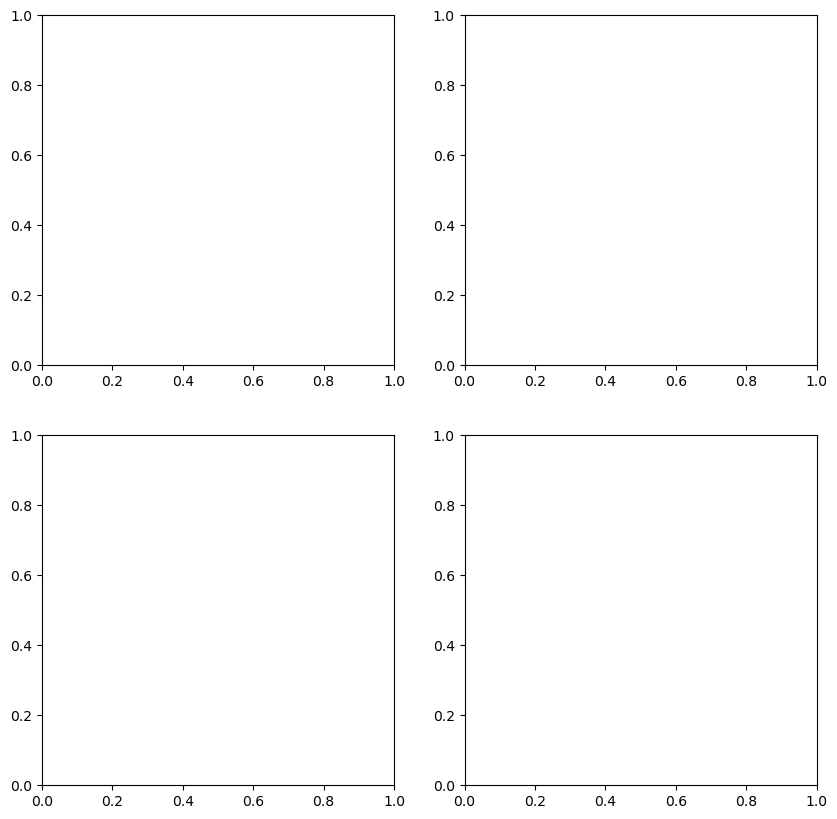

In [61]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10));

In [58]:
slingshot = Slingshot(adata, celltype_key="celltype", obsm_key="X_umap", start_node=5)

slingshot.fit(num_epochs=1, debug_axes=axes)  # we can change the number of epochs for better training

  0%|          | 0/1 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

In [59]:
# should i use 

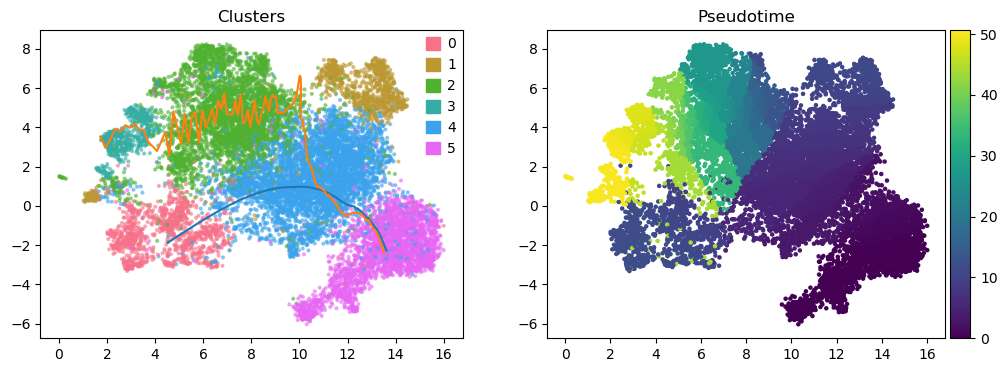

In [60]:

fig, axes = plt.subplots(ncols=2, figsize=(12, 4))
axes[0].set_title("Clusters")
axes[1].set_title("Pseudotime")
slingshot.plotter.curves(axes[0], slingshot.curves)
slingshot.plotter.clusters(axes[0], labels=np.arange(slingshot.num_clusters), s=4, alpha=0.5)
slingshot.plotter.clusters(axes[1], color_mode="pseudotime", s=5)

In [62]:
slingshot = Slingshot(adata, celltype_key="celltype", obsm_key="X_umap", start_node=4)

slingshot.fit(num_epochs=1, debug_axes=axes)  # we can change the number of epochs for better training


fig, axes = plt.subplots(ncols=2, figsize=(12, 4))
axes[0].set_title("Clusters")
axes[1].set_title("Pseudotime")
slingshot.plotter.curves(axes[0], slingshot.curves)
slingshot.plotter.clusters(axes[0], labels=np.arange(slingshot.num_clusters), s=4, alpha=0.5)
slingshot.plotter.clusters(axes[1], color_mode="pseudotime", s=5)

KeyboardInterrupt: 


KeyboardInterrupt



In [11]:
# see differences between UMAP without scANVI ? and see..

In [16]:
projected_points, mst, centroids = learn_graph(matrix=adata.obsm['X_umap'], clusters=adata.obs['celltype'])

In [17]:
pseudotime = order_cells(
    adata.obsm['X_umap'], 
    centroids,
    mst=mst,
    projected_points=projected_points,
    root_cells=0,
)

In [18]:
umap = adata.obsm['X_umap']
louvain = adata.obs['celltype']

In [25]:
# we should define a palette for our analysis.
palette_cd4 = {
    "Naive":  "#4C72B0",   # blue
    "Tfh":    "#DD8452",   # orange
    "Th17":   "#55A868",   # green
    "Treg":   "#C44E52",   # red
}

palette_cd8 = {
    "CD8_naive": "skyblue",
    "CD8_mem": "green",
    "CD8_ex": "red",
    "CD8_ex_act": "purple",
    "CD8_eff": "navy",
    "CD8_act": "gold",
}

adata.obs["celltype_color"] = adata.obs["celltype"].map(palette_cd8)

color = adata.obs['celltype_color']

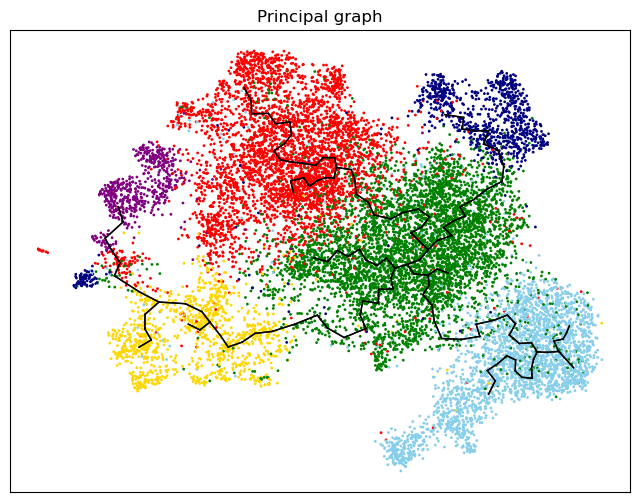

In [26]:
plt.figure(1, (8, 6))
plt.title("Principal graph")
plt.scatter(umap[:, 0], umap[:, 1], c=color, s=1, cmap="nipy_spectral") 

# i need to change and put a palette for the celltypes.

edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(centroids[edge, 0], centroids[edge, 1], c="black", linewidth=1)
plt.xticks([])
plt.yticks([])
plt.show()

In [22]:
root_celltype = "CD8_naive"


sc.pp.neighbors(adata, use_rep="X_pca") #aqui podem fer servir també l'altre clau... 
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, use_rep="X_diffmap")
sc.tl.paga(adata, groups="celltype")

iroot = np.flatnonzero(adata.obs["celltype"] == root_celltype)[0]
adata.uns["iroot"] = iroot
sc.tl.dpt(adata)


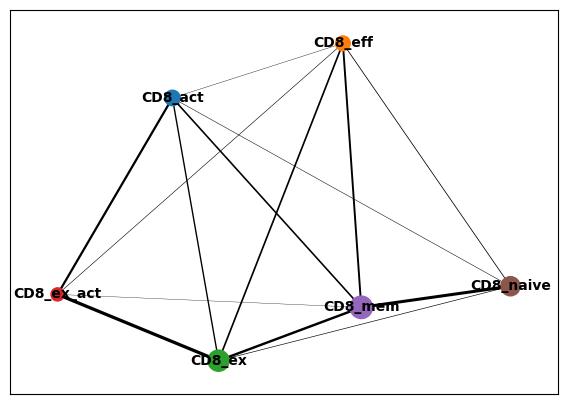

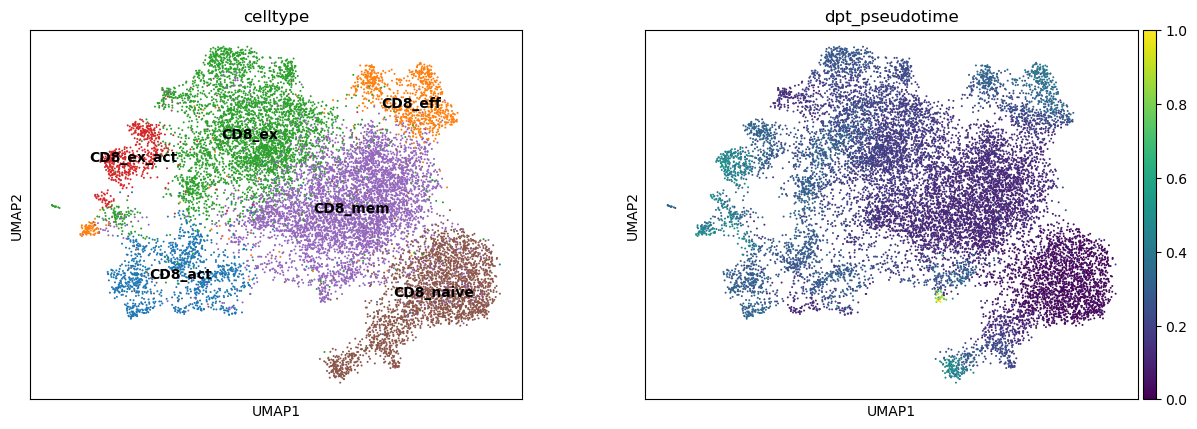

In [23]:
sc.pl.paga(adata, color=["celltype"])
sc.pl.umap(adata, color=["celltype", "dpt_pseudotime"], legend_loc="on data")

In [36]:
collectri = dc.op.collectri(organism="human")
progeny = dc.op.progeny(organism="human")
hallmark = dc.op.hallmark(organism="human")

In [37]:
dc.mt.ulm(data=adata, net=collectri)
score = dc.pp.get_obsm(adata=adata, key="score_ulm")


In [38]:
tfs = dc.tl.rankby_order(
    adata=score,
    order="dpt_pseudotime",
    stat="dcor",
)
tfs

,name,stat,pval,padj
0,RFX5,1689.640402,0.0,0.0
1,RFXANK,1689.640402,0.0,0.0
2,NFKB2,1539.767925,0.0,0.0
3,RFXAP,1489.263268,0.0,0.0
4,VSX2,1392.828888,0.0,0.0
...,...,...,...,...
377,KDM5A,26.947213,0.0,0.0
378,FOSB,26.436458,0.0,0.0
379,NR4A3,26.060321,0.0,0.0
380,TTF1,25.442965,0.0,0.0


In [39]:
top_tfs = tfs.head(10)["name"].to_list()
#top_tfs

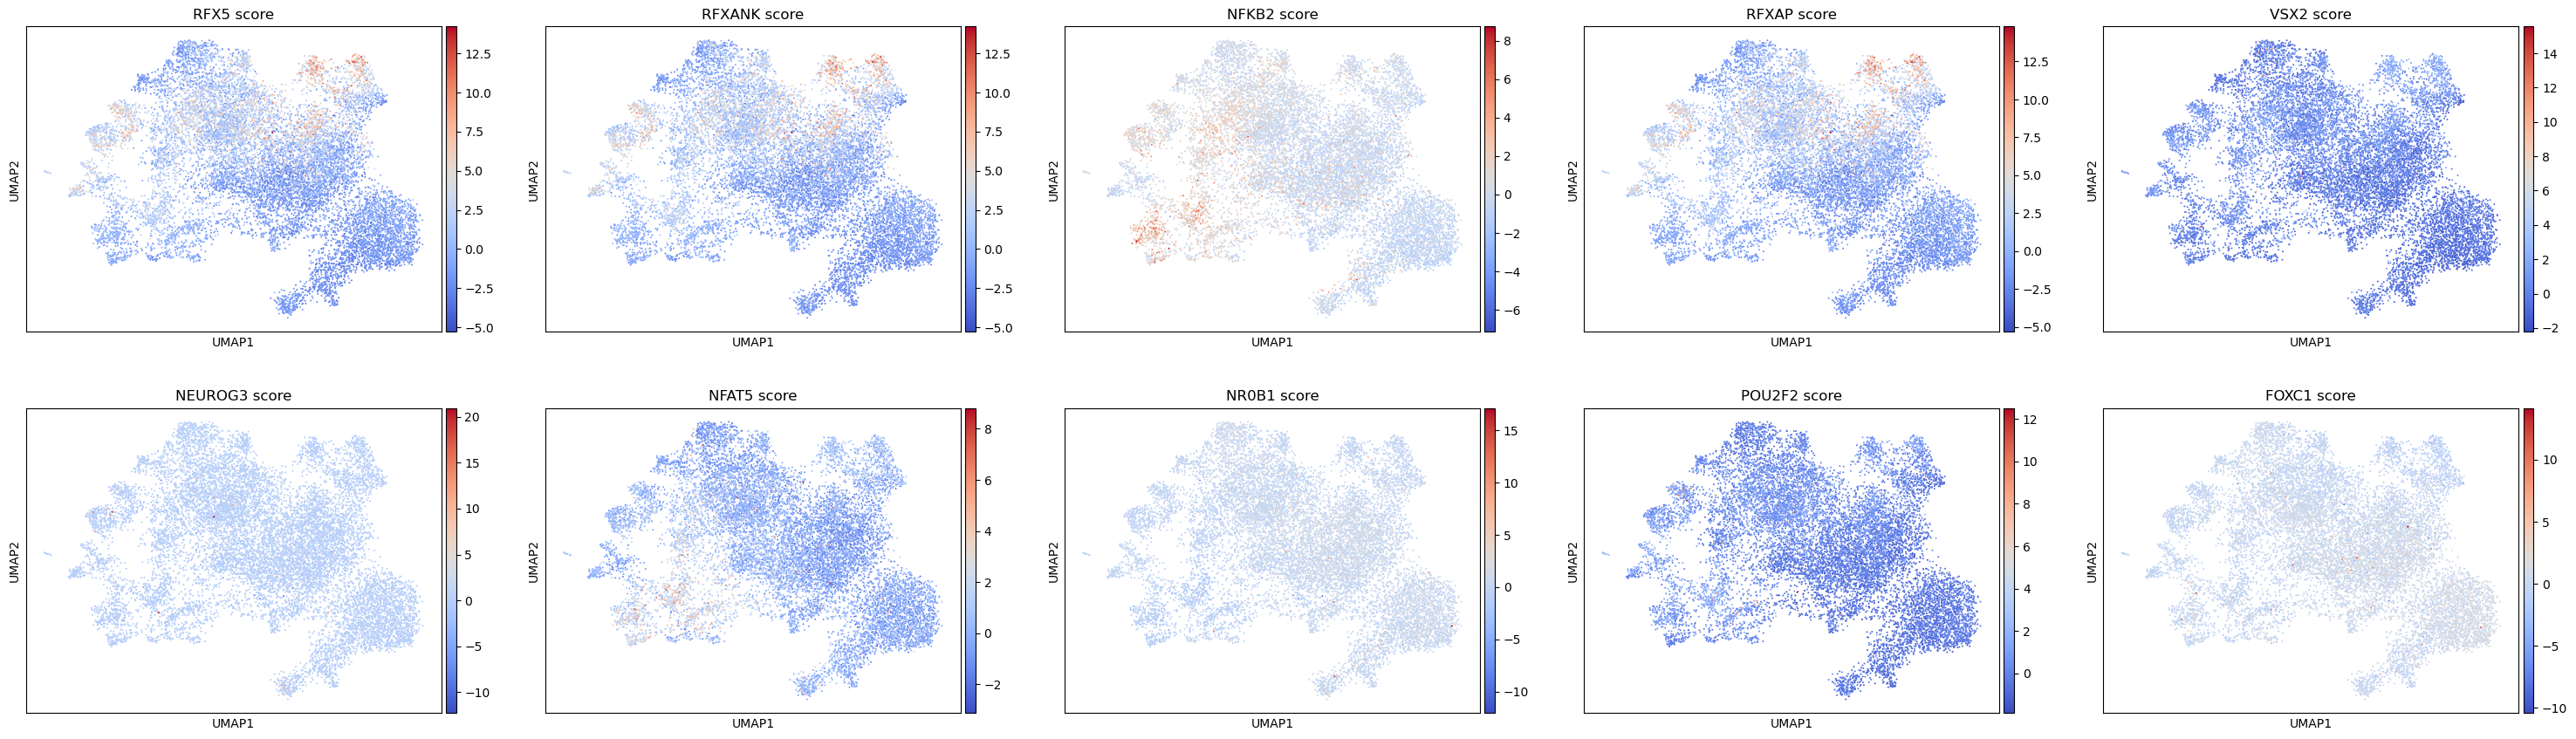

In [40]:
sc.pl.umap(score, color=top_tfs, cmap="coolwarm", ncols=5, title=[f"{t} score" for t in top_tfs]) #vmin=-5, vmax=5, 

In [41]:
bin_tfs = dc.pp.bin_order(
    adata=score,
    order="dpt_pseudotime",
    names=top_tfs,
    label="celltype",
)
bin_tfs

,name,order,value,label,color
0,RFX5,0.005,-1.675967,CD8_naive,#8c564b
1,RFX5,0.005,0.057108,CD8_naive,#8c564b
2,RFX5,0.005,-0.890778,CD8_mem,#9467bd
3,RFX5,0.005,-0.896805,CD8_naive,#8c564b
4,RFX5,0.005,-2.983223,CD8_naive,#8c564b
...,...,...,...,...,...
143845,FOXC1,0.965,0.219081,CD8_mem,#9467bd
143846,FOXC1,0.985,0.311157,CD8_mem,#9467bd
143847,FOXC1,0.995,0.130388,CD8_mem,#9467bd
143848,FOXC1,0.995,-0.608555,CD8_mem,#9467bd


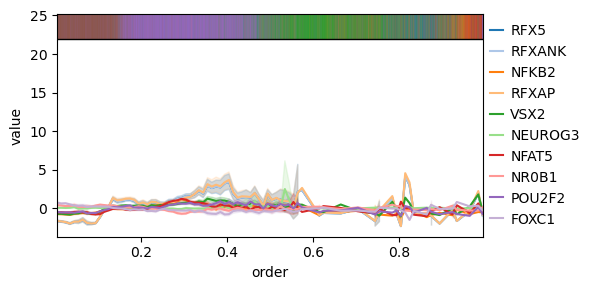

In [42]:
dc.pl.order(
    df=bin_tfs,
    mode="line",
    figsize=(6, 3),
)

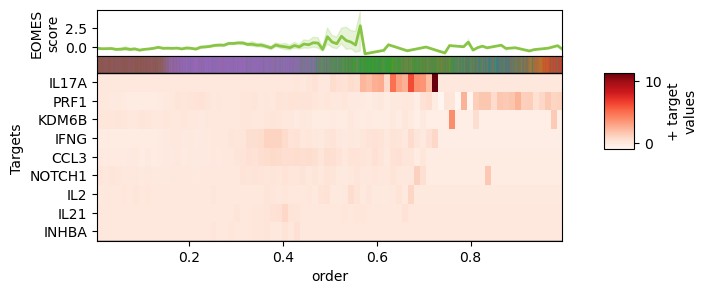

In [44]:
dc.pl.order_targets(
    adata=adata,
    net=collectri,
    label="celltype",
    source="EOMES",
    order="dpt_pseudotime",
)

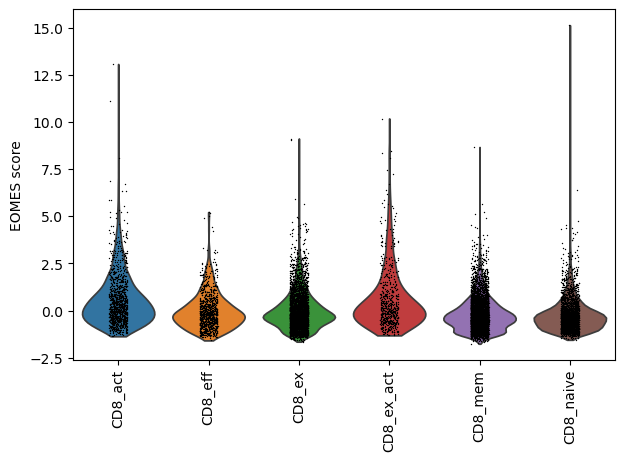

In [43]:
tf = "EOMES"
sc.pl.violin(score, keys=[tf], groupby="celltype", rotation=90, ylabel=f"{tf} score")